# CME 241 — Phase 2 Report
## Multi-Strategy Statistical Arbitrage via Discrete MDP and Value Iteration

---

Goal: solve a simplified multi-strategy allocation problem using dynamic programming on a finite, discrete Markov Decision Process (MDP).

---
## 1. Problem setup and Phase 2 simplification

We allocate wealth across two risky strategy return streams plus cash, rebalancing at discrete times.

Phase 2 simplifications (relative to Phase 1):
- Strategy set is fixed and small (2 strategies).
- State is low-dimensional: discretized wealth $W_t$ and an optional 2-state market regime $R_t \in \{\text{good}, \text{bad}\}$. $\text{Good}$ regime indicates low volatility, while $\text{bad}$ regime indicates high volatility (relative to recent history).
- Actions are a small discrete menu of allocations (Conservative/Balanced/Aggressive).
- Return dynamics are modeled parametrically (Gaussian, optionally regime-conditional).
- We solve the resulting finite MDP with value iteration.

Decision convention: choose $a_t$ at time $t$, then earn returns over $(t, t+1]$.

---
## 2. Data source and preprocessing

Data source:
We use daily S&P 500 panel from CRSP (Center for Research in Security Prices), which is a standard finance dataset that provides historical data for US traded securities.

In this project, the CRSP daily S&P 500 panel is a table with one row per stock per trading day, including:

- Identifiers:
  - `PERMNO`: stable security identifier (does not change even if the ticker changes)
  - `TICKER` / `COMNAM`: ticker and company name (can change over time)

- Trading and returns:
  - `RET`: daily return
  - `DLRET`: delisting return (used when a stock stops trading; important for avoiding survivorship bias)
  - `PRC`: price
  - `VOL`: volume
  - `SHROUT`: shares outstanding

- Classification / filters:
  - `SHRCD`: share code (used to keep common shares, e.g., 10/11)
  - `EXCHCD`: exchange code (used to keep major US exchanges, e.g., 1/2/3)

Why we use it here:
- It lets us build clean, survivorship-aware daily return series and then construct strategy portfolios from those returns.

Data-quality policy implemented in the notebook:
1. Time: parse dates, sort, check monotonicity.
2. Identifiers: filter to primary common equity (SHRCD ∈ {10,11}) and US exchanges (EXCHCD ∈ {1,2,3}); deduplicate (PERMNO, date).
3. Values: merge delisting returns (DLRET) into final returns when available.
4. Missing data: do not fill RET; drop dates with return coverage < 90%; flag extreme returns (e.g., $|RET|>50\%$) for inspection.
5. Causal normalization: rolling volatility and rolling z-scores (no full-sample statistics).

Concrete pipeline outputs recorded in the notebook run:
- Loaded 8,480,706 rows (1003 PERMNOs), 1960-01-04 to 2023-03-31
- After SHRCD/EXCHCD filter: 8,213,445 rows
- After integrity checks: 8,211,167 rows
- Final stock-level panel: 8,210,791 rows, 965 PERMNOs
- Extreme returns flagged: 240 observations with $|RET|>50\%$
- Dropped 1 date for low coverage (1972-12-14, coverage 0.816489)
- Winsorized 1.153% of valid return observations (rolling z-score cap at 3.0)

---
## 3. Strategy return series (two strategies)

The notebook builds two causal daily strategy return streams from the cleaned CRSP panel using rolling volatility quintiles:

- Strategy 1 (conservative): equal-weighted daily returns of the lowest rolling-vol quintile
- Strategy 2 (aggressive): equal-weighted daily returns of the highest rolling-vol quintile

Volatility signal:
- 21-day rolling volatility, lagged (uses yesterday’s information), so quintile assignment is fully causal.

The constructed strategy dataset has shape (15909, 5), including:
- `strat1_ret`, `strat2_ret` (strategy returns)
- `vwretd`, `ewretd`, `sprtrn` (market reference series in the file)

Descriptive statistics of daily returns (reported in the notebook):

- Strategy 1: mean 0.000463, std 0.006649, min -0.072767, 25% -0.002439, 50% 0.000696, 75% 0.003619, max 0.069302
- Strategy 2: mean 0.000977, std 0.016162, min -0.153509, 25% -0.006272, 50% 0.001324, 75% 0.008451, max 0.150565

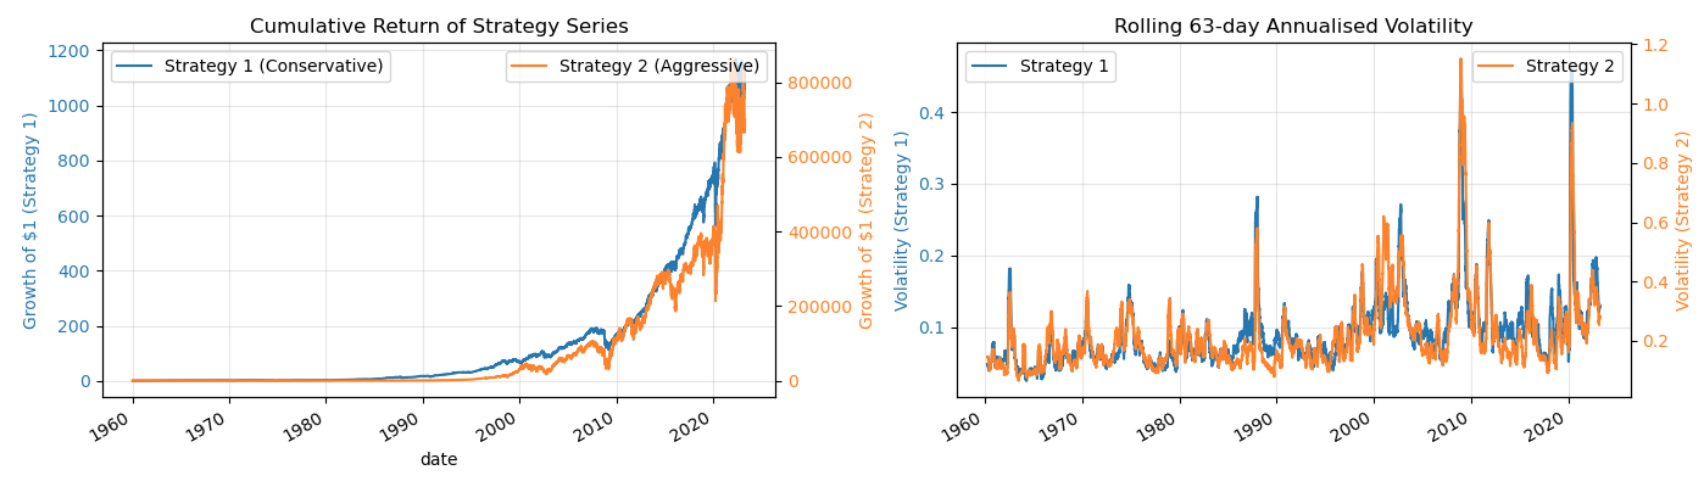

**Figure 1:** left hand side plot shows the cumulative returns for each strategy. The right hand side plot shows rolling 63 day annulaized volatility.

---
## 4. Parametric calibration (Gaussian + optional regime)

### 4.1 Return model

Let $r_{t+1} = (r^{(1)}_{t+1}, r^{(2)}_{t+1})$ be the two strategy returns.

Unconditional model:
$$
r_{t+1} \sim \mathcal{N}(\mu, \Sigma).
$$

Optional 2-state regime model:
$$
r_{t+1} \mid (R_t = r) \sim \mathcal{N}(\mu_r, \Sigma_r), \quad r \in \{\text{good}, \text{bad}\},
$$
with $R_t$ following a 2×2 Markov transition matrix.

### 4.2 Regime definition (causal)

Regime is defined using market returns `vwretd`:
- compute rolling 21-day realized volatility of `vwretd`
- compare to its own rolling median over the past 105 days
- low-vol days are labeled “good”, high-vol days are labeled “bad”

### 4.3 Estimated parameters (reported in the notebook)

Period: 1960-01-18 → 2023-03-31 (15909 observations)

Regime counts:
- 8387 good days (52.7%)
- 7522 bad days

Unconditional:
- Strategy 1: $\mu = +0.00046,\ \sigma = 0.00665$
- Strategy 2: $\mu = +0.00098,\ \sigma = 0.01616$
- Correlation: $\rho = 0.7265$

Regime-conditional:

Good regime:
- Strategy 1: $\mu = +0.00059,\ \sigma = 0.00499$
- Strategy 2: $\mu = +0.00114,\ \sigma = 0.01269$
- $\rho = 0.6611$

Bad regime:
- Strategy 1: $\mu = +0.00032,\ \sigma = 0.00811$
- Strategy 2: $\mu = +0.00079,\ \sigma = 0.01931$
- $\rho = 0.7565$

Regime transition matrix (rows = current state, columns = next state; order [bad, good]):
- bad row:  [0.94349156, 0.05650844]
- good row: [0.05067366, 0.94932634]

These transition probabilities imply persistent regimes (self-transition probabilities near 0.94–0.95).

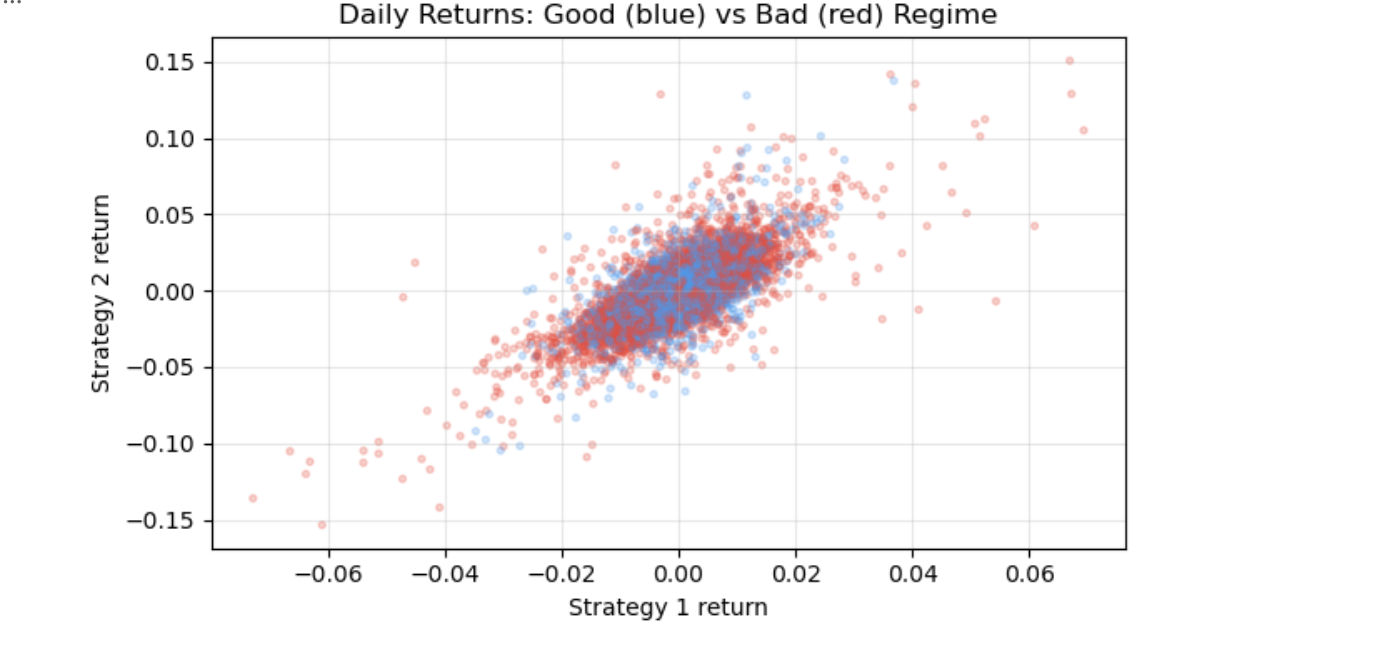

**Figure 2:** scatter of daily returns for each strategy.

---
## 5. MDP definition

### 5.1 State space

We discretize wealth onto a log-spaced grid:
- $W \in \{w_1, \ldots, w_{40}\}$
- $w_1 = 0.5$, $w_{40} = 2.0$
- initial wealth $W_0 = 1.0$

With regime enabled, the state is:
$$
s_t = (W_t, R_t), \quad R_t \in \{\text{good}, \text{bad}\}.
$$

In the notebook run, this yields 80 non-terminal states (40 wealth bins × 2 regimes).

### 5.2 Action space

Three discrete allocations across Strategy 1 / Strategy 2 / Cash:
- Conservative: 80% / 20% / 0%
- Balanced:     50% / 50% / 0%
- Aggressive:   20% / 80% / 0%

### 5.3 Wealth transition

Ignoring transaction costs (transaction_cost = 0.0 in the main run):
$$
W_{t+1} = W_t\big(1 + a_t^\top r_{t+1}\big),
$$
where $a_t$ is the chosen allocation across the two strategies (cash is 0% in this action set).

Transition discretization:
- the notebook approximates $P(s' \mid s,a)$ using 3,000 Monte Carlo draws per (state, action) pair from the calibrated Gaussian model (and regime transition when enabled).

### 5.4 Reward (CRRA utility increment)

CRRA utility with risk aversion parameter $\gamma$:
$$
U(W)=\begin{cases}
\frac{W^{1-\gamma}-1}{1-\gamma}, & \gamma \neq 1 \\
\log W, & \gamma=1
\end{cases}
$$

Reward is:
$$
R(s_t, a_t, s_{t+1}) = U(W_{t+1}) - U(W_t).
$$

Notebook configuration for utility curvature:
- CRRA $\gamma = 2$

---
## 6. Value iteration (solution method)

We solve an infinite-horizon discounted MDP using value iteration.

To avoid notation collision with CRRA $\gamma$, denote the MDP discount factor by $\beta$.

Bellman optimality equation:
$$
V^*(s) = \max_{a \in A}\sum_{s'} P(s' \mid s,a)\Big(R(s,a,s') + \beta V^*(s')\Big).
$$

Value iteration updates:
$$
V_{k+1}(s) \leftarrow \max_{a \in A}\sum_{s'} P(s' \mid s,a)\Big(R(s,a,s') + \beta V_k(s')\Big).
$$

Notebook setting for discounting:
- $\beta = 0.99$

Outputs:
- optimal value function $V^*$
- optimal policy $\pi^*(s)$ (reported with a policy summary table over wealth bins and regimes)

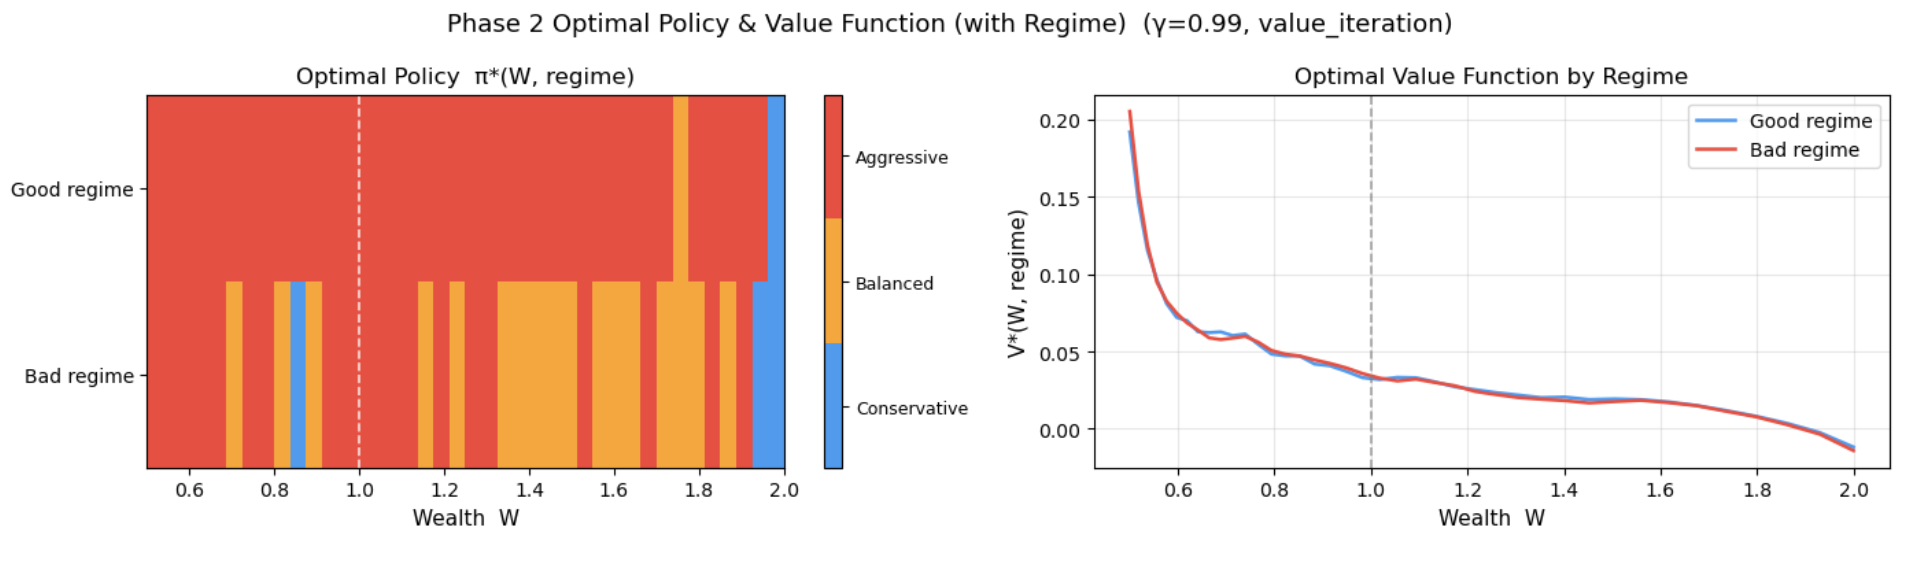

**Figure 3**: Optimal policy for MDP with different volatility regimes.

---
## 7. Policy summary and interpretation

The notebook prints a policy summary table of the form:

Wealth, Regime → Action and implied allocation (S1/S2/Cash)

This allows inspection of:
- how the optimal action changes across the wealth grid
- where the policy differs between good and bad regimes

In the recorded run, the policy differs between regimes for some wealth bins, reflecting the regime-conditional calibration (different $\mu$, $\sigma$, and $\rho$ in good vs bad).

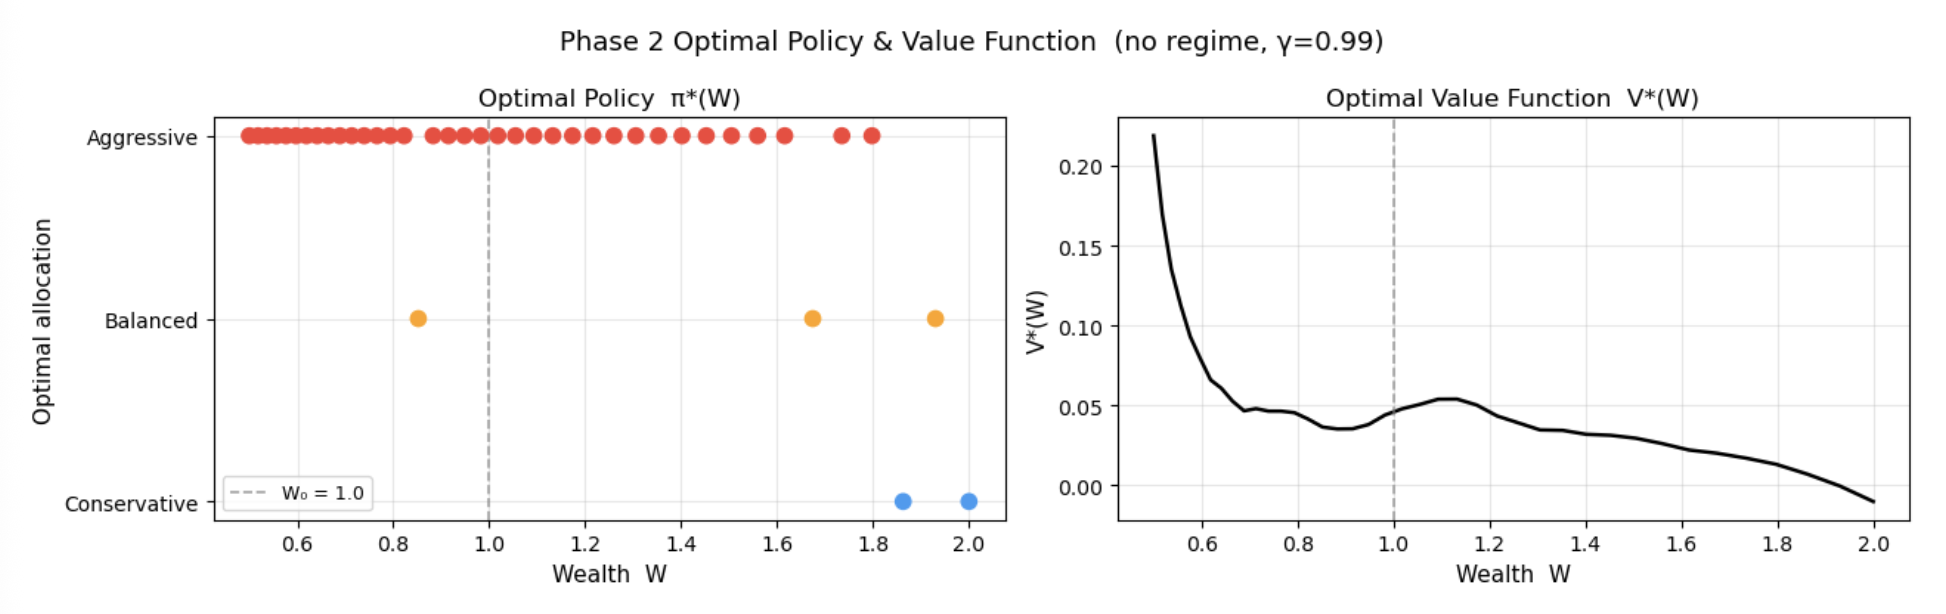

**Figure 4:** Optimal Policy and Value function in MDP without considering volatility regimes.

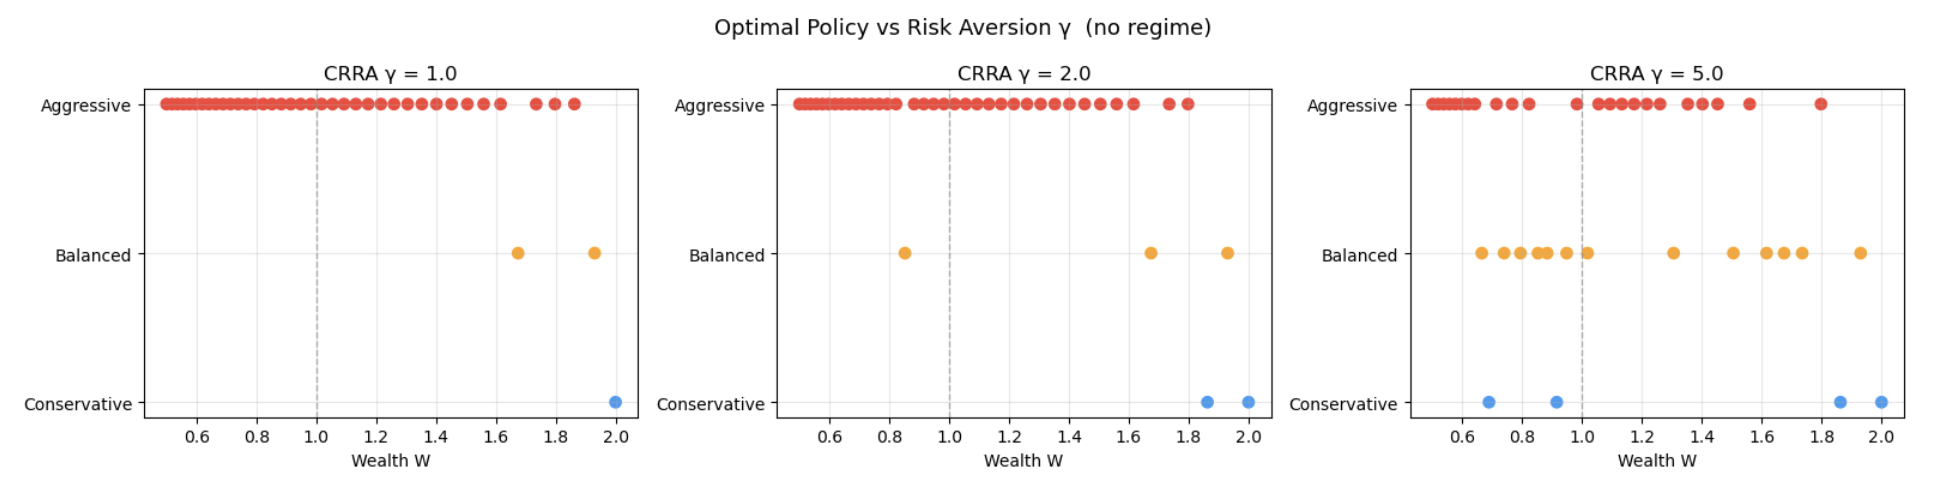

**Figure 5**: Optimal Policy  for different $γ$ values.

---
## 9. Key observations


1. Regime effect: in the bad regime, the optimal policy is more conservative at the same wealth level, pulling back from Strategy 2 (higher volatility) when expected returns are lower and volatility is higher.

2. Risk aversion: higher CRRA $\gamma$ shifts the entire policy toward more conservative allocations, and the wealth threshold at which the agent switches to a riskier allocation increases.

3. Curse of dimensionality: even this small MDP (40 wealth × 2 regimes × 3 actions) required careful discretization. The realistic Phase 3 version (continuous state, many strategies) requires RL.